In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from pathlib import Path

In [5]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "code":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_DIR = BASE_DIR / "data" / "processed"
FIGURE_DIR = BASE_DIR / "figures"
RESULT_DIR = BASE_DIR / "results"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)



In [6]:
# ============================================================
# 1. ĐỌC TRAIN DATA
# ============================================================

price_train = pd.read_csv(
    DATA_DIR / "price_train.csv",
    parse_dates=["Date"]
)

return_train = pd.read_csv(
    DATA_DIR / "return_train.csv",
    parse_dates=["Date"]
)

print("Đọc dữ liệu thành công!")

print("\nPrice train:")
print(price_train.shape)

print("\nReturn train:")
print(return_train.shape)

print("\nThời gian:")
print(
    price_train["Date"].min(),
    "->",
    price_train["Date"].max()
)

Đọc dữ liệu thành công!

Price train:
(3871, 6)

Return train:
(3870, 7)

Thời gian:
2010-01-04 00:00:00 -> 2024-12-31 00:00:00


In [7]:
# ============================================================
# 2. THỐNG KÊ MÔ TẢ GIÁ
# ============================================================

print("\n" + "=" * 65)
print("THỐNG KÊ MÔ TẢ GIÁ BẠC")
print("=" * 65)

print(price_train["Close"].describe())


THỐNG KÊ MÔ TẢ GIÁ BẠC
count    3871.000000
mean       22.034168
std         6.322668
min        11.954500
25%        16.940000
50%        20.230000
75%        25.808000
max        48.460000
Name: Close, dtype: float64


In [8]:
# ============================================================
# 3. THỐNG KÊ MÔ TẢ LOG-RETURN
# ============================================================

r = return_train["log_return"].dropna()

print("\n" + "=" * 65)
print("THỐNG KÊ LOG-RETURN")
print("=" * 65)

print(r.describe())

print("\nMean:")
print(r.mean())

print("\nStandard deviation:")
print(r.std())

print("\nSkewness:")
print(skew(r, bias=False))

print("\nExcess Kurtosis:")
print(
    kurtosis(
        r,
        fisher=True,
        bias=False
    )
)



THỐNG KÊ LOG-RETURN
count    3870.000000
mean        0.013082
std         1.804976
min       -16.080396
25%        -0.805834
50%         0.046740
75%         0.898484
max         8.512776
Name: log_return, dtype: float64

Mean:
0.013082029081687199

Standard deviation:
1.8049761590203146

Skewness:
-0.7750746030996769

Excess Kurtosis:
7.4461207556392495


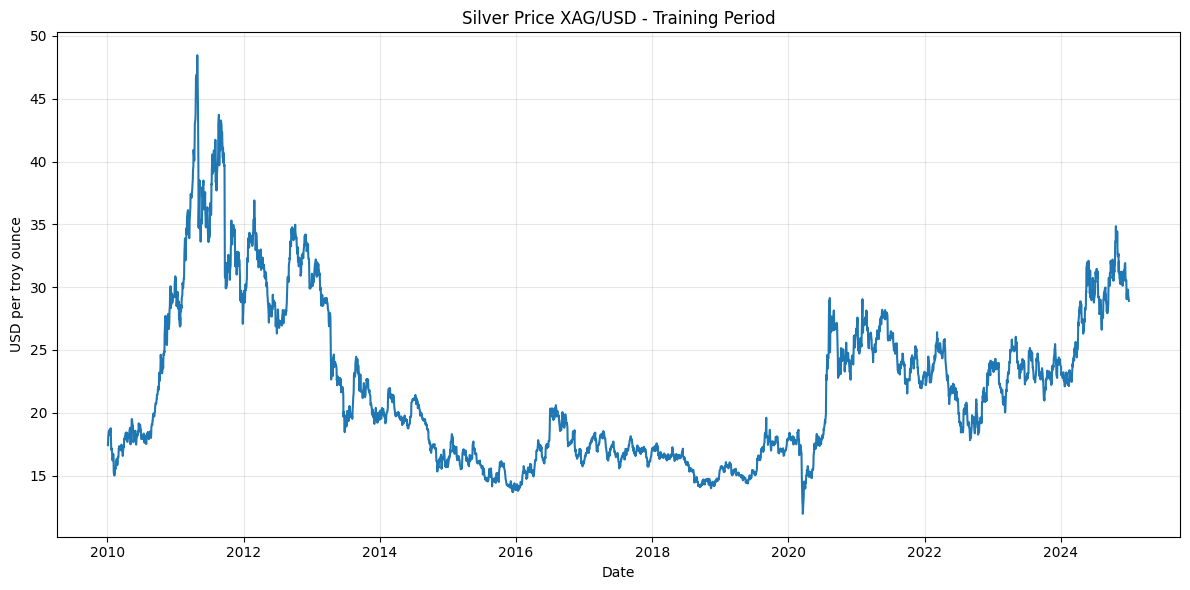

In [9]:
# ============================================================
# 4. ĐỒ THỊ GIÁ BẠC
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    price_train["Date"],
    price_train["Close"]
)

plt.title(
    "Silver Price XAG/USD - Training Period"
)

plt.xlabel("Date")
plt.ylabel("USD per troy ounce")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "01_silver_price.png",
    dpi=300
)

plt.show()



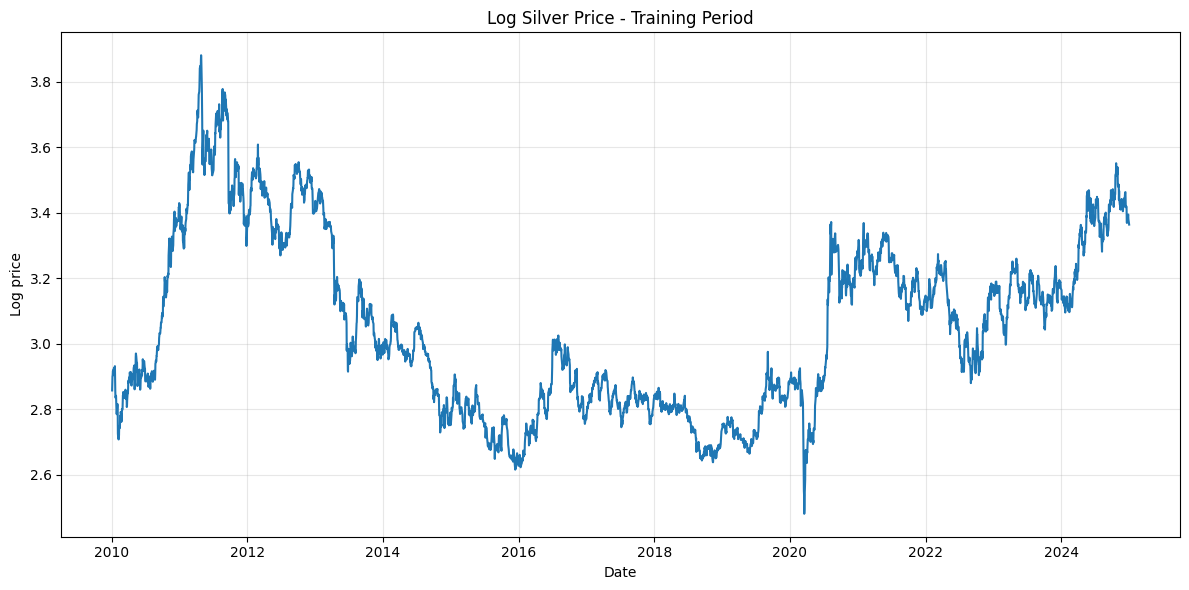

In [10]:
# ============================================================
# 5. ĐỒ THỊ LOG-PRICE
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    price_train["Date"],
    price_train["log_price"]
)

plt.title(
    "Log Silver Price - Training Period"
)

plt.xlabel("Date")
plt.ylabel("Log price")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "02_log_price.png",
    dpi=300
)

plt.show()


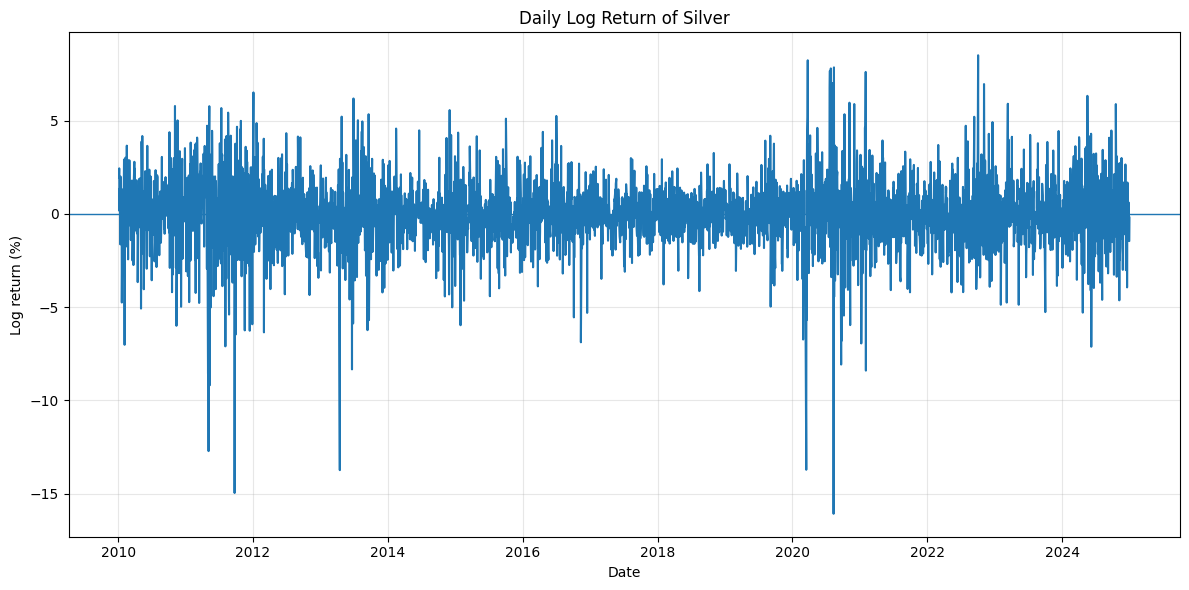

In [11]:
# ============================================================
# 6. ĐỒ THỊ LOG-RETURN
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    return_train["Date"],
    return_train["log_return"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.title(
    "Daily Log Return of Silver"
)

plt.xlabel("Date")
plt.ylabel("Log return (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "03_log_return.png",
    dpi=300
)

plt.show()


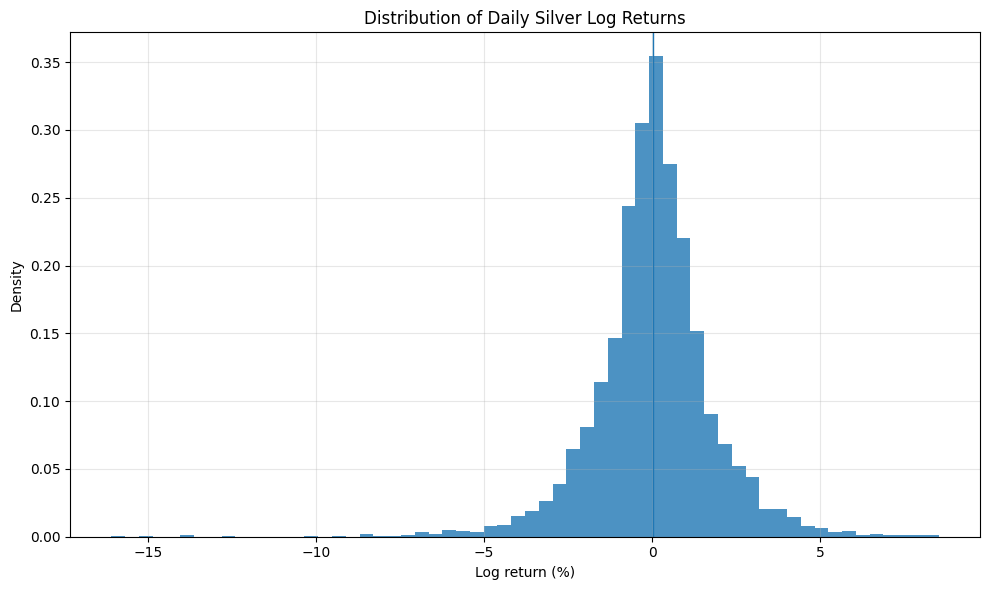

In [12]:
# ============================================================
# 7. HISTOGRAM LOG-RETURN
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    r,
    bins=60,
    density=True,
    alpha=0.8
)

plt.axvline(
    r.mean(),
    linewidth=1
)

plt.title(
    "Distribution of Daily Silver Log Returns"
)

plt.xlabel("Log return (%)")
plt.ylabel("Density")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "04_return_histogram.png",
    dpi=300
)

plt.show()


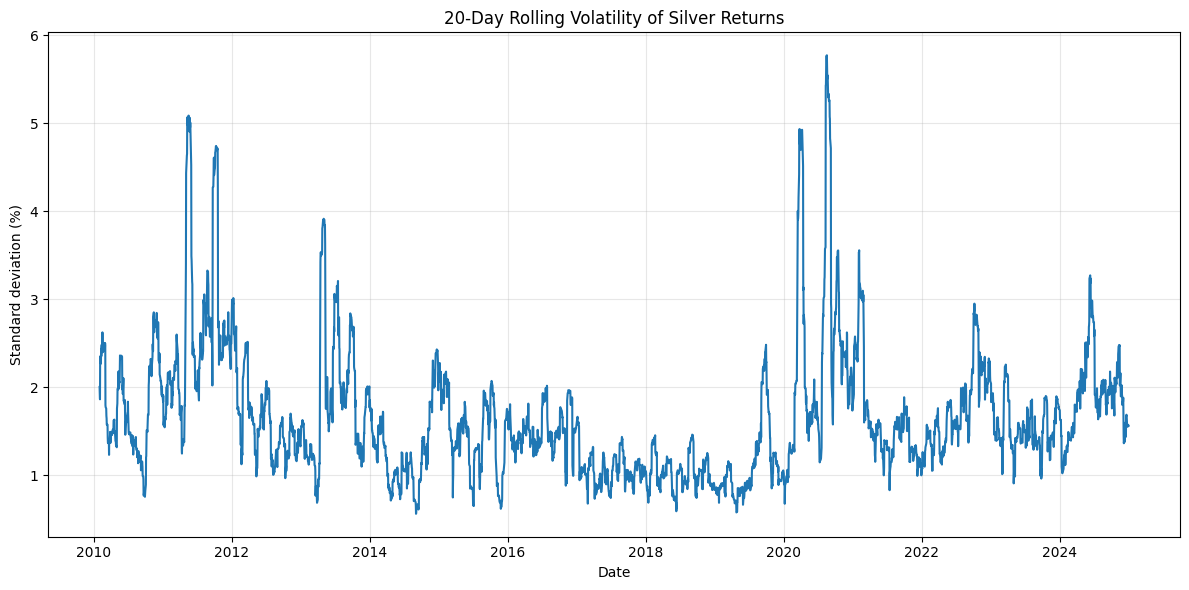

In [13]:
# ============================================================
# 8. ROLLING VOLATILITY
# ============================================================

return_train["rolling_vol_20"] = (
    return_train["log_return"]
    .rolling(window=20)
    .std()
)

plt.figure(figsize=(12, 6))

plt.plot(
    return_train["Date"],
    return_train["rolling_vol_20"]
)

plt.title(
    "20-Day Rolling Volatility of Silver Returns"
)

plt.xlabel("Date")
plt.ylabel("Standard deviation (%)")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "05_rolling_volatility.png",
    dpi=300
)

plt.show()


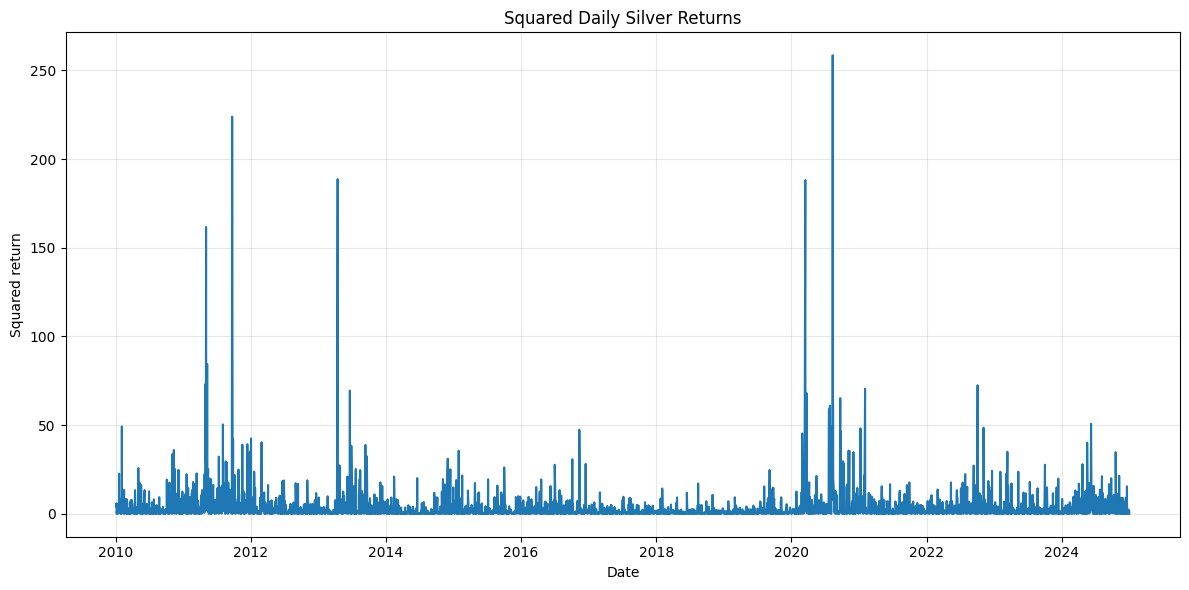

In [14]:
# ============================================================
# 9. SQUARED RETURN
# ============================================================

if "squared_return" not in return_train.columns:
    return_train["squared_return"] = (
        return_train["log_return"] ** 2
    )

plt.figure(figsize=(12, 6))

plt.plot(
    return_train["Date"],
    return_train["squared_return"]
)

plt.title(
    "Squared Daily Silver Returns"
)

plt.xlabel("Date")
plt.ylabel("Squared return")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "06_squared_return.png",
    dpi=300
)

plt.show()



In [15]:
# ============================================================
# 10. TÌM NHỮNG NGÀY BIẾN ĐỘNG LỚN
# ============================================================

largest_moves = (
    return_train[
        ["Date", "Close", "log_return"]
    ]
    .assign(
        abs_return=lambda x:
        x["log_return"].abs()
    )
    .sort_values(
        "abs_return",
        ascending=False
    )
    .head(20)
)

print("\n" + "=" * 65)
print("20 PHIÊN CÓ |LOG-RETURN| LỚN NHẤT")
print("=" * 65)

print(
    largest_moves[
        ["Date", "Close", "log_return"]
    ].to_string(index=False)
)




20 PHIÊN CÓ |LOG-RETURN| LỚN NHẤT
      Date   Close  log_return
2020-08-11 24.8030  -16.080396
2011-09-23 30.8500  -14.964878
2013-04-15 22.6450  -13.738793
2020-03-16 12.8155  -13.719212
2011-05-05 34.7300  -12.717666
2011-09-22 35.8300  -10.029608
2011-05-11 35.1200   -9.188747
2011-05-02 43.9800   -8.558927
2022-10-03 20.7095    8.512776
2021-02-02 26.7000   -8.401062
2013-06-20 19.6750   -8.334095
2020-03-24 14.4140    8.243039
2020-09-21 24.7300   -8.075787
2020-08-13 27.6000    7.862765
2020-07-27 24.6000    7.807141
2020-07-22 23.0000    7.678714
2021-02-01 29.0400    7.617623
2020-03-13 14.7000   -7.522736
2024-06-07 29.1725   -7.120598
2011-08-04 38.8700   -7.099755


In [16]:
# ============================================================
# 11. LƯU THỐNG KÊ
# ============================================================

summary = pd.DataFrame({
    "Statistic": [
        "Observations",
        "Mean return",
        "Std return",
        "Minimum return",
        "Maximum return",
        "Skewness",
        "Excess kurtosis"
    ],

    "Value": [
        len(r),
        r.mean(),
        r.std(),
        r.min(),
        r.max(),
        skew(r, bias=False),
        kurtosis(
            r,
            fisher=True,
            bias=False
        )
    ]
})

summary.to_csv(
    RESULT_DIR / "eda_summary.csv",
    index=False
)

print("\nĐã lưu:")
print("figures/01_silver_price.png")
print("figures/02_log_price.png")
print("figures/03_log_return.png")
print("figures/04_return_histogram.png")
print("figures/05_rolling_volatility.png")
print("figures/06_squared_return.png")
print("results/eda_summary.csv")


Đã lưu:
figures/01_silver_price.png
figures/02_log_price.png
figures/03_log_return.png
figures/04_return_histogram.png
figures/05_rolling_volatility.png
figures/06_squared_return.png
results/eda_summary.csv
